# Air Quality Data in India | City Day | EDA

# Loading the libraries

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Loading the dataset

In [3]:
cd = pd.read_csv("./data/city_day.csv")
cd.head(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
cd.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 4.3 MB


# Data Cleaning and Preparation

In [5]:
# Check for duplicates 
print("Duplicate rows:", cd.duplicated().sum())
cd = cd.drop_duplicates()

# Convert 'Date' to datetime format 
cd['Date'] = pd.to_datetime(cd['Date'], errors='coerce')



Duplicate rows: 0


In [6]:
# Checking for null values in each column
null_values = cd.isnull().sum()

print("Null values in each column:")
print(null_values)


Null values in each column:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [10]:
# Removing rows with any null values
data_cleaned = cd.dropna()

print(f"Original dataset shape: {cd.shape}")
print(f"Cleaned dataset shape: {data_cleaned.shape}")

Original dataset shape: (29531, 16)
Cleaned dataset shape: (6236, 16)


In [14]:
# Filling null values with zero
data_filled = data_cleaned.fillna(0)

In [15]:
# Verify if null values remain
print("Null values after cleaning:")
print(data_cleaned.isnull().sum())

Null values after cleaning:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64


# Visualizations

**Distribution of Air Quality Index (AQI)**

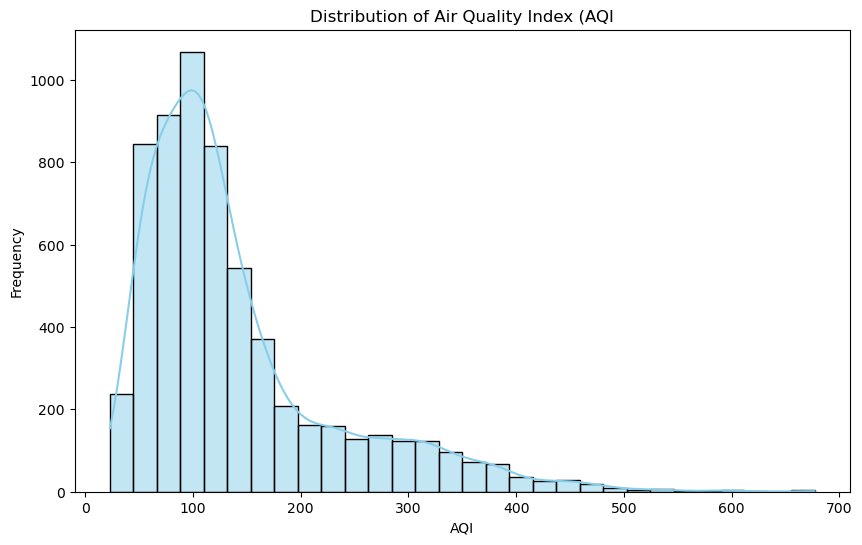

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(data_cleaned['AQI'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Air Quality Index (AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

* Skewness:
The distribution is positively skewed (right-skewed), as most of the AQI values are concentrated in the lower range (below 200), with a long tail extending to the right.

* Peak/Mode:
The highest frequency of AQI values occurs around 100, indicating that this is the most common AQI range.

* Range:
The AQI values span from near 0 to around 700, but values beyond 500 are rare.

* Smooth Density Curve:
The density curve adds visual clarity, showing the general trend of AQI distribution and helping highlight the tail.

**City-wise AQI Analysis**

In [ ]:
city_aqi = data_cleaned.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
city_aqi.plot(kind='bar',color='coral')
plt.title('Top 10 Cities with the Highest Average AQI')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45)
plt.show()

* Delhi has the highest average AQI, significantly surpassing the others.
* There’s a noticeable decline in AQI as we move from the first city to the last, though the differences between some cities are relatively smaller.

In [ ]:
unique_cities = data_cleaned['City'].nunique()
print(f"The total number of unique cities in the dataset is {unique_cities}.")

**AQI Trends Over Time**

In [ ]:
plt.figure(figsize=(12,6))
data_cleaned.groupby('Date')['AQI'].mean().plot(color='green')
plt.title('AQI Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.show()

# Observations:
* Initial High AQI (2015-2016):
The AQI levels are significantly higher during the early period (2015 to mid-2016), indicating poorer air quality during this time.

* Gradual Decline in AQI (Post-2016):
There is a notable decline in average AQI levels after 2016, followed by relatively stable fluctuations in subsequent years.
This may indicate improved air quality measures or environmental factors influencing pollution levels.

* Periodic Spikes:
Sharp spikes in AQI are visible throughout the graph, with the most prominent ones occurring around 2018 and 2019.
These spikes could be due to specific seasonal or environmental events like crop burning, festivals, or industrial activity.

* Recent Trends (2019-2020):
Toward the end of the graph (2019-2020), the AQI seems to stabilize at comparatively lower levels, which might suggest consistent improvements in air quality.

# Insights:
* Seasonal/Annual Patterns:
Further analysis can determine if these spikes align with certain times of the year, such as winter, when pollution from heating and weather inversions can lead to poor air quality.

* Improvement Efforts:
The overall decline post-2016 may be linked to policy measures (e.g., stricter emission controls, bans on specific industrial activities) or broader environmental changes.

* 2020 Trends:
The relatively lower levels in 2020 could correlate with events like COVID-19 lockdowns, which drastically reduced vehicular and industrial emissions.

**PM2.5 and PM10 Levels Analysis**

Comparing the distributions of PM2.5 and PM10

In [ ]:
plt.figure(figsize=(12,6))
sns.kdeplot(data_cleaned['PM2.5'], label='PM2.5', color='blue', fill=True)
sns.kdeplot(data_cleaned['PM10'], label='PM10', color='orange', fill=True)

plt.title('Comparison of PM2.5 and PM10 Levels')
plt.xlabel('Concentration')
plt.ylabel('Density')
plt.legend()
plt.show()

Observations:
* Peak Density Comparison:
The PM2.5 curve (blue) peaks at a lower concentration compared to PM10 (orange), indicating that PM2.5 concentrations are generally lower than PM10.

* Distribution Spread:
The PM2.5 distribution is narrower and more concentrated around its peak.
The PM10 distribution is broader, with a heavier tail extending to higher concentrations, showing that PM10 values tend to have more extreme variations.

* Overlap:
There is significant overlap between PM2.5 and PM10 distributions in the lower concentration range, as expected, since PM2.5 is a subset of PM10.

* Heavier Tail for PM10:
The long tail of the PM10 distribution indicates occasional high concentrations that are not as prevalent for PM2.5.
Insights:

* Health Implications:
PM2.5 particles, being smaller, are more dangerous for human health as they can penetrate deeper into the lungs and bloodstream. Despite their lower concentrations, their narrow distribution may signal consistently harmful exposure levels.

* Emission Sources:
The broader range of PM10 concentrations suggests diverse sources, such as road dust, construction, and agricultural activities, whereas PM2.5 concentrations may predominantly arise from combustion-related sources (e.g., vehicles, and industrial emissions).

* AQI Contributions:
The higher variability of PM10 concentrations might have a more substantial impact on fluctuating AQI levels, especially during events like dust storms.


**AQI Bucket Distribution**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='AQI_Bucket', data=data_cleaned, palette='viridis')  # Corrected here
plt.title('Distribution of AQI Buckets')
plt.xlabel('AQI Bucket')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Observations:

* Dominant Categories:
The "Moderate" category has the highest count, followed by the "Satisfactory" category. Together, these two categories dominate the distribution.

* Lower Frequency of Severe Pollution:
The "Severe" category has the lowest count, indicating fewer instances of extremely poor air quality.

* Skew Towards Better Air Quality:
A significant portion of the data lies in the "Satisfactory" and "Moderate" ranges, suggesting that air quality is generally within acceptable levels most of the time.

* Presence of "Poor" and "Very Poor" Levels:
The "Poor" and "Very Poor" categories still account for a considerable share, highlighting occasional concerning pollution levels.
Insights:

* Health Implications:
While the majority of instances fall under "Moderate" and "Satisfactory," the presence of "Poor," "Very Poor," and "Severe" levels indicates episodic periods where air quality could pose health risks, particularly for sensitive groups.

* Seasonal or Geographical Factors:
The distribution might vary significantly across seasons or locations. For example, "Very Poor" and "Severe" levels could align with events like industrial emissions, crop burning, or winter smog.

* Focus on Reduction:
Interventions might be targeted to reduce occurrences in the "Poor" and "Very Poor" categories, as they represent the most manageable opportunities for improvement.

# Answering Questions

**Correlation between AQI and PM2.5**

In [ ]:
aqi_pm25_corr = cd[['AQI','PM2.5']].corr().iloc[0,1]
print(f"The correlation between AQI and PM2.5 is {aqi_pm25_corr:.2f}")

**Total Number of Unique Cities in the Dataset**

In [ ]:
unique_cities = cd['City'].nunique()
print(f"The total number of unique cities in the dataset is {unique_cities}.")

**Date with the Highest Average AQI**

In [ ]:
highest_aqi_date = cd.groupby('Date')['AQI'].mean().idxmax()
highest_aqi_value = cd.groupby('Date')['AQI'].mean().max()

print(f"The data with the highest average AQI is {highest_aqi_date} with an AQI of {highest_aqi_value:.2f}")

**City with the Highest PM2.5 Levels on an Average**

In [ ]:
city_highest_pm25 = cd.groupby('City')['PM2.5'].mean().idxmax()
highest_pm25_value = cd.groupby('City')['PM2.5'].mean().max()

print(f"The city with the highest average PM2.5 is {city_highest_pm25} with PM2.5 concentration of {highest_pm25_value:.2f}")

**Correlation between AQI and PM2.5**

In [ ]:
aqi_pm25_corr = cd[['AQI','PM2.5']].corr().iloc[0,1]
print(f"The correlation between AQI and PM2.5 is {aqi_pm25_corr:.2f}")

**Overall Average for Key Pollutants**

In [ ]:
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']
pollutants_avg = cd[pollutants].mean()

print("Overall Average Values for Key Pollutants:")
print(pollutants_avg)

**Number of Days with AQI > 300 (Severe Air Quality)**

In [ ]:
severe_aqi_days = (cd['AQI'] > 300).sum()
print(f"The number of days with AQI greater than 300 (severe) is {severe_aqi_days}.")

**Top 5 cities with maximum variance in AQI**

In [ ]:
city_aqi_variance = cd.groupby('City')['AQI'].var().sort_values(ascending=False).head(5)

print("Top 5 Cities with Maximum AQI Variance:")
print(city_aqi_variance)

# Inferences

* Ahmedabad has the highest AQI variance (97,175.31), indicating extreme fluctuations in air quality, followed by Patna, Gurugram, Delhi, and Lucknow.
* There were 3,675 days with AQI greater than 300, indicating prolonged severe air quality posing significant health risks.
* Patna has the highest average PM2.5 concentration at 123.50, highlighting it as a pollution hotspot.
* A 0.66 correlation between AQI and PM2.5 suggests that PM2.5 is a major driver of poor air quality.
* The worst recorded AQI was 764 on 2015-02-23, indicating an extreme pollution event.
* Key pollutants like PM2.5 (67.45), PM10 (118.13), and nitrogen oxides dominate, mainly due to vehicular and industrial emissions.
* The dataset covers 26 cities, showing widespread air quality issues, with city-specific interventions required to combat pollution.

# Summary


The analysis highlights significant air quality concerns across various cities. **Ahmedabad** showed the highest AQI variance (97,175.31), followed by **Patna**, **Gurugram**, **Delhi**, and **Lucknow**, indicating fluctuating and unstable air quality in these regions. There were **3,675 days** with AQI levels above 300, marking severe pollution and posing serious health risks.  

**Patna** recorded the highest **average PM2.5 concentration** at **123.50**, confirming it as a critical pollution hotspot. The correlation between **AQI and PM2.5** was found to be **0.66**, suggesting that PM2.5 is a major factor influencing overall air quality. The **worst recorded AQI** was **764** on **2015-02-23**, reflecting an extreme pollution episode.  

Key pollutants, including **PM2.5 (67.45)**, **PM10 (118.13)**, and nitrogen oxides, indicate significant contributions from vehicular emissions, industrial activities, and biomass burning. With data covering **26 cities**, the findings emphasize the urgent need for targeted pollution control measures and city-specific interventions to mitigate air quality degradation.  

## Practical-4 Submission Section (Minimum Required)

This section covers:
- Descriptive statistics
- Missing value handling
- Correlation matrix
- Line plot, boxplots, histograms, and heatmap
- Short interpretation of findings

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

candidate_paths = ["data/city_day.csv", "city_day.csv"]
chosen_path = None
for p in candidate_paths:
    if os.path.exists(p):
        chosen_path = p
        break

if chosen_path is None:
    raise FileNotFoundError("city_day.csv not found. Place it at data/city_day.csv or city_day.csv")

df = pd.read_csv(chosen_path)
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

pollutants = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene", "AQI"]
available_num = [c for c in pollutants if c in df.columns]

print("Dataset shape:", df.shape)
print("Numeric pollutant columns used:", available_num)

# Descriptive statistics and dispersion summary
stats_df = df[available_num].describe().T
stats_df["median"] = df[available_num].median()
stats_df["range"] = stats_df["max"] - stats_df["min"]
stats_df = stats_df[["mean", "median", "std", "min", "25%", "50%", "75%", "max", "range"]]
print("\nDescriptive statistics:")
display(stats_df)

# Missing value analysis
missing = df[available_num].isna().sum().sort_values(ascending=False)
print("\nMissing values (selected columns):")
display(missing.to_frame("missing_count"))

df_clean = df.copy()
df_clean[available_num] = df_clean[available_num].fillna(df_clean[available_num].median(numeric_only=True))

# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[available_num].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Pollutants and AQI")
plt.tight_layout()
plt.show()

# Histograms
df_clean[available_num].hist(figsize=(14, 10), bins=30)
plt.suptitle("Pollutant Distributions", y=1.02)
plt.tight_layout()
plt.show()

# Boxplots for key pollutants
box_cols = [c for c in ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3", "AQI"] if c in available_num]
if box_cols:
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df_clean[box_cols])
    plt.title("Boxplots for Key Pollutants")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# Line plot trend over time (AQI)
if "Date" in df_clean.columns and "AQI" in df_clean.columns:
    trend = df_clean.dropna(subset=["Date"]).groupby("Date", as_index=False)["AQI"].mean().sort_values("Date")
    plt.figure(figsize=(12, 5))
    plt.plot(trend["Date"], trend["AQI"], color="teal")
    plt.title("Average AQI Trend Over Time")
    plt.xlabel("Date")
    plt.ylabel("Average AQI")
    plt.tight_layout()
    plt.show()

print("\nInterpretation (minimum):")
print("1) Central tendency and spread show which pollutants have high variability.")
print("2) Missing values were handled using median imputation for numeric pollutant columns.")
print("3) Correlation heatmap indicates pollutant pairs and relationship with AQI.")
print("4) Histograms and boxplots reveal skewness and possible outliers.")
print("5) AQI line trend highlights time-based pollution changes.")